In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point, Polygon

(np.float64(-0.5), np.float64(1199.5), np.float64(1199.5), np.float64(-0.5))

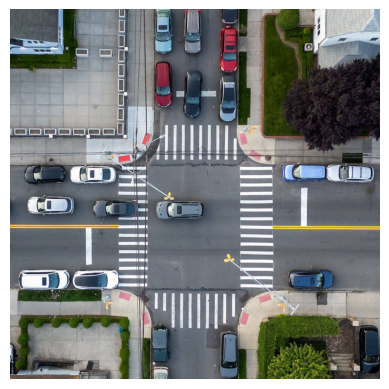

In [2]:
img = cv2.imread("IMG_20260608_233848_316.jpg")
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")

In [27]:
model = YOLO("yolov8x-world.pt")

In [15]:
print(img.shape)

(1200, 1200, 3)


In [16]:
results = model("IMG_20260608_233848_316.jpg",
                imgsz = 1280,
                conf = 0.1,
                verbose = True)


image 1/1 C:\Users\sadila\data mining\IMG_20260608_233848_316.jpg: 1280x1280 22 cars, 1 truck, 2 potted plants, 10560.4ms
Speed: 24.6ms preprocess, 10560.4ms inference, 4.7ms postprocess per image at shape (1, 3, 1280, 1280)


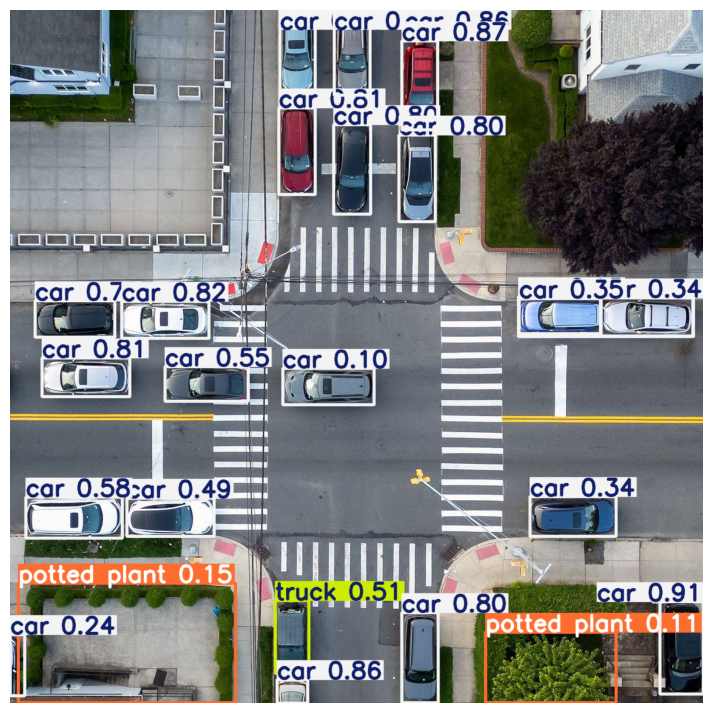

In [30]:
annotated = results[0].plot()
plt.figure(figsize=(9,9))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

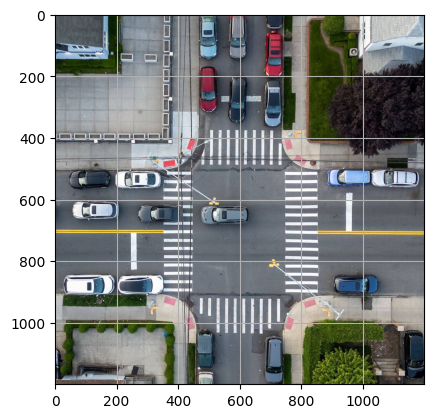

In [19]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.grid()
plt.show()

In [21]:
ROI ={
    "top_roi":Polygon([(420,0),   (820,0),   (820,380),  (420,380)]),
    "bottom_roi":Polygon([(350,840), (850,840), (850,1200),  (350,1200)  ]),
    "right_roi":Polygon([(870,430), (1200,430),   (1200,700),    (870,700)]),
    "left_roi":Polygon([(0,430),   (330,430), (330,900),  (0,900)])
}

In [22]:
#vehicle_centers

def get_vehicles_center(results):
    centers = []
    for box in results[0].boxes:
        cls = int(box.cls[0])
        if model.names[cls]  not in ["car", "truck"]:
             continue
        x1,y1,x2,y2 = box.xyxy[0]
        cx = float((x1+x2)/2)
        cy = float((y1+y2)/2)
        centers.append((cx,cy))
        
    return centers 
    
#count in ROI
def count_cars(get_vehicles_center,roi):
    count = 0
    for cx,cy in get_vehicles_center:
        if roi.contains(Point(cx,cy)):
            count+=1
            
    return count   

In [23]:
#count all vehicles 
vehicles_center = get_vehicles_center(results)

print("total_cars :", len(vehicles_center))

total_cars : 23


In [24]:
#count cars in top ROI
top_count=count_cars(vehicles_center,ROI["top_roi"])
print("top_roi :",top_count)

top_roi : 7


In [25]:
# Count cars in each ROI
for roi_name, roi_poly in ROI.items():
    count = count_cars(vehicles_center, roi_poly)
    print (f"{roi_name}:{count}")

top_roi:7
bottom_roi:3
right_roi:3
left_roi:5
